In [2]:
import sys
from pathlib import Path
project_root = Path.cwd().parent
code_root = project_root / "neuralbi_diff" / "gbi_diff"
code_root = project_root / "neuralbi_diff"
sys.path.extend([str(project_root), str(code_root)])
print(sys.path)

['/home/robin/miniconda3/envs/gbi/lib/python312.zip', '/home/robin/miniconda3/envs/gbi/lib/python3.12', '/home/robin/miniconda3/envs/gbi/lib/python3.12/lib-dynload', '', '/home/robin/miniconda3/envs/gbi/lib/python3.12/site-packages', '/home/robin/projects/lab_project/neuralgbi_diffusion', '/home/robin/projects/lab_project/neuralgbi_diffusion/neuralbi_diff']


In [3]:
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import matplotlib.pylab as plab
import numpy as np
import torch
from sourcerer.simulators import TwoMoonsSimulator
from torch import Tensor
from tqdm import tqdm

from gbi_diff.model.lit_module import Guidance
from gbi_diff.sampling.diffusion import DiffusionSampler
from gbi_diff.sampling.utils import load_specified_data, load_misspecified_data
from gbi_diff.utils.configs.sampling_diffusion import Config
from gbi_diff.utils.criterion import SBICriterion
from gbi_diff.utils.metrics import compute_distances, mse_dist,mmd_dist
from gbi_diff.utils.plot import _pair_plot
import matplotlib as mpl
import seaborn as sns
from notebooks.plot_utils import get_guidance_analytics, plot_corr, plot_guidance_analytics_1D


colors_tab10 = mpl.colormaps["tab10"]
colors_tab20 = mpl.colormaps["tab20"]


# specify matplotlib rc file
plt.style.use(str(project_root / ".matplotlibrc"))

/home/robin/miniconda3/envs/gbi/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
res_net_guidance_ckpt = "/home/robin/projects/lab_project/neuralgbi_diffusion/results/train_guidance/uniform/2025-03-29-19-57-13/lightning_logs/version_0/epoch=99-step=4000.ckpt"
guidance = Guidance.load_from_checkpoint(res_net_guidance_ckpt)

Compute <lambda> distances: 100%|██████████| 1000/1000 [00:00<00:00, 83205.46sample/s]

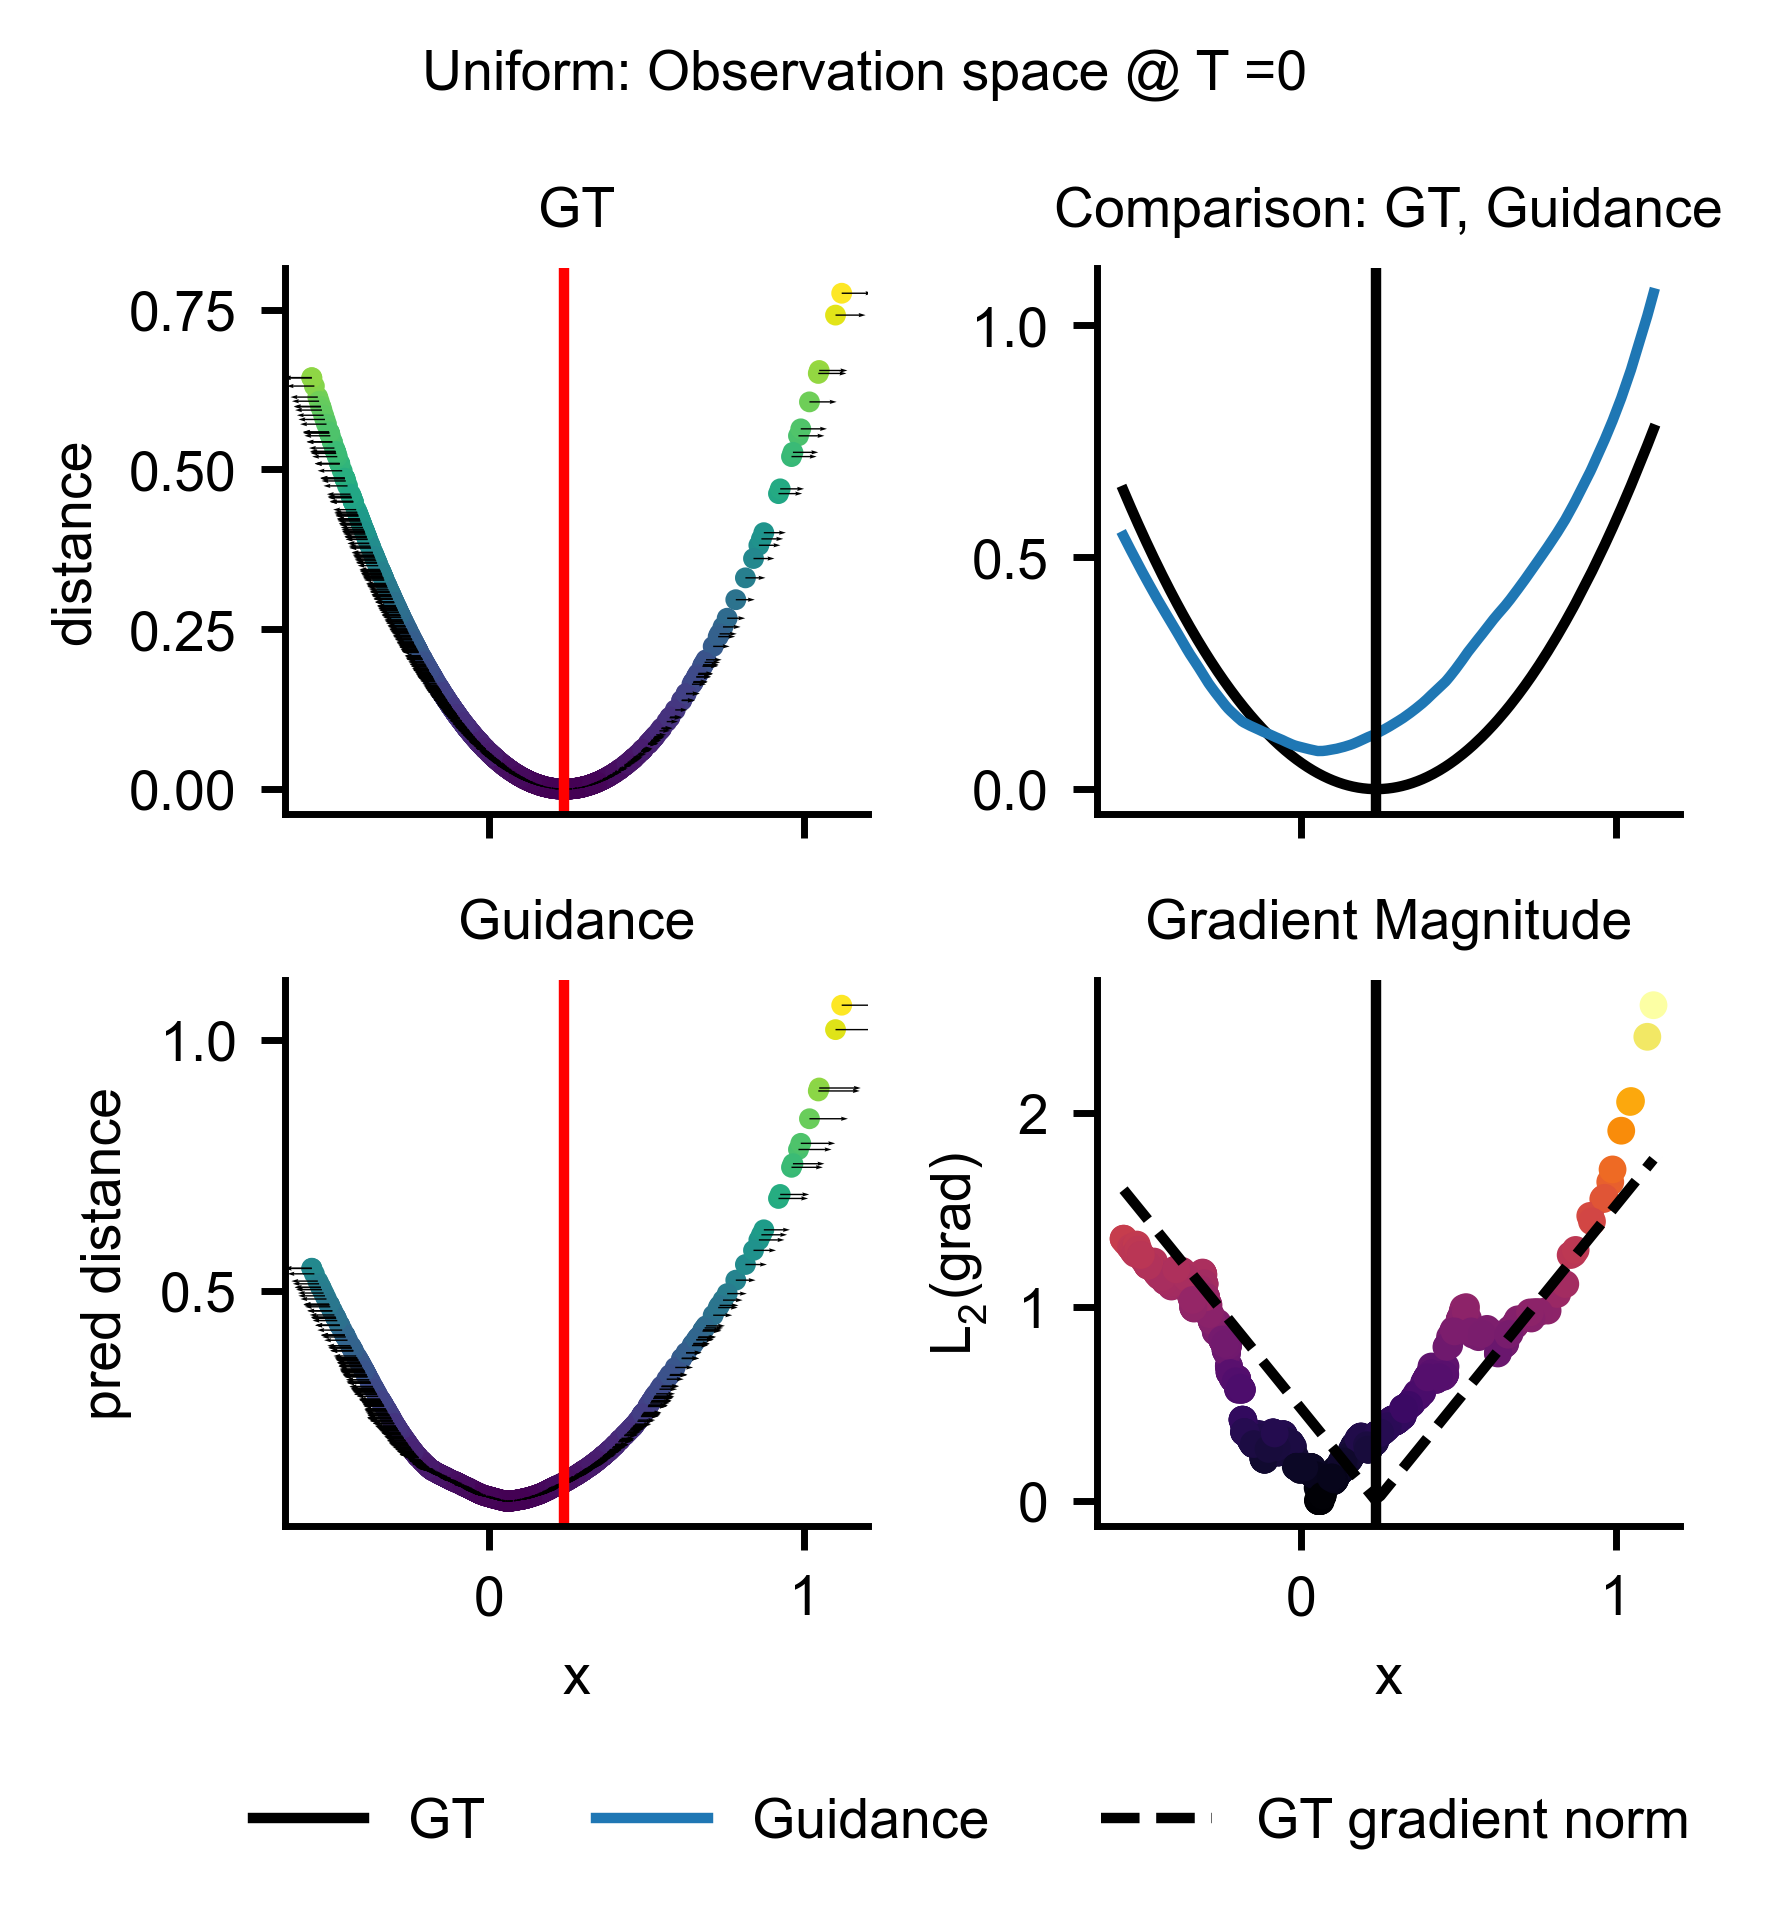

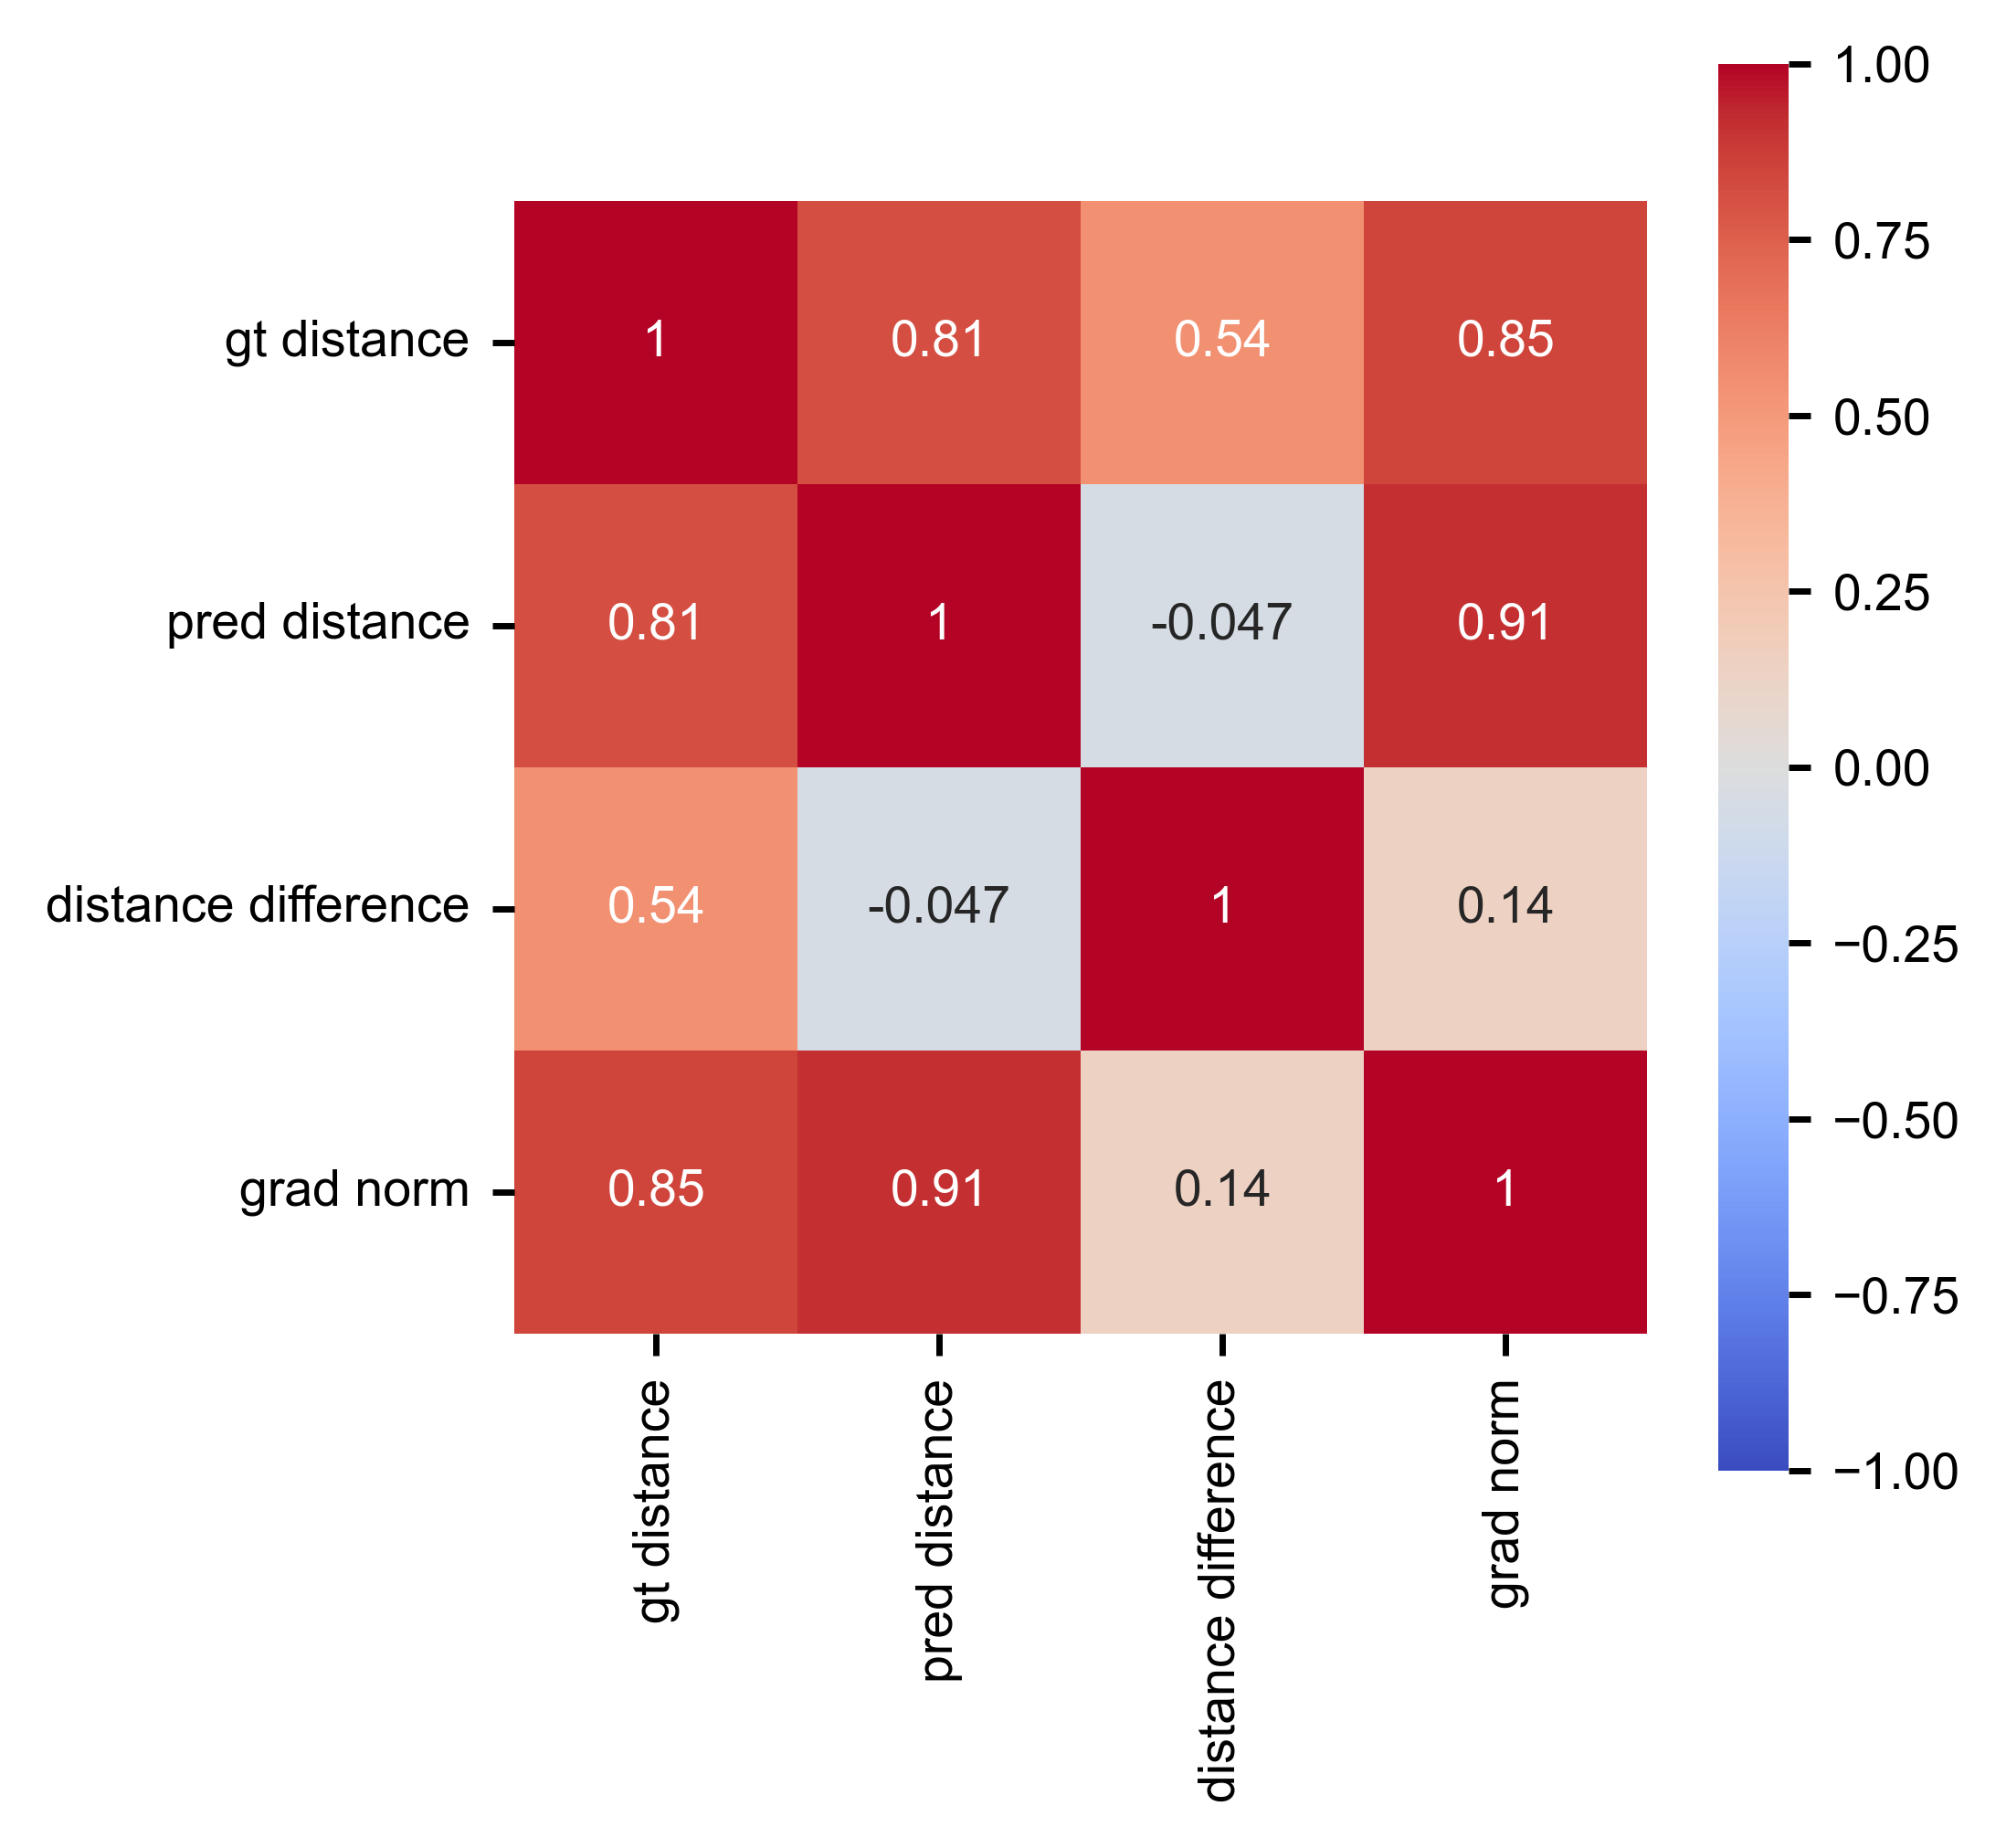

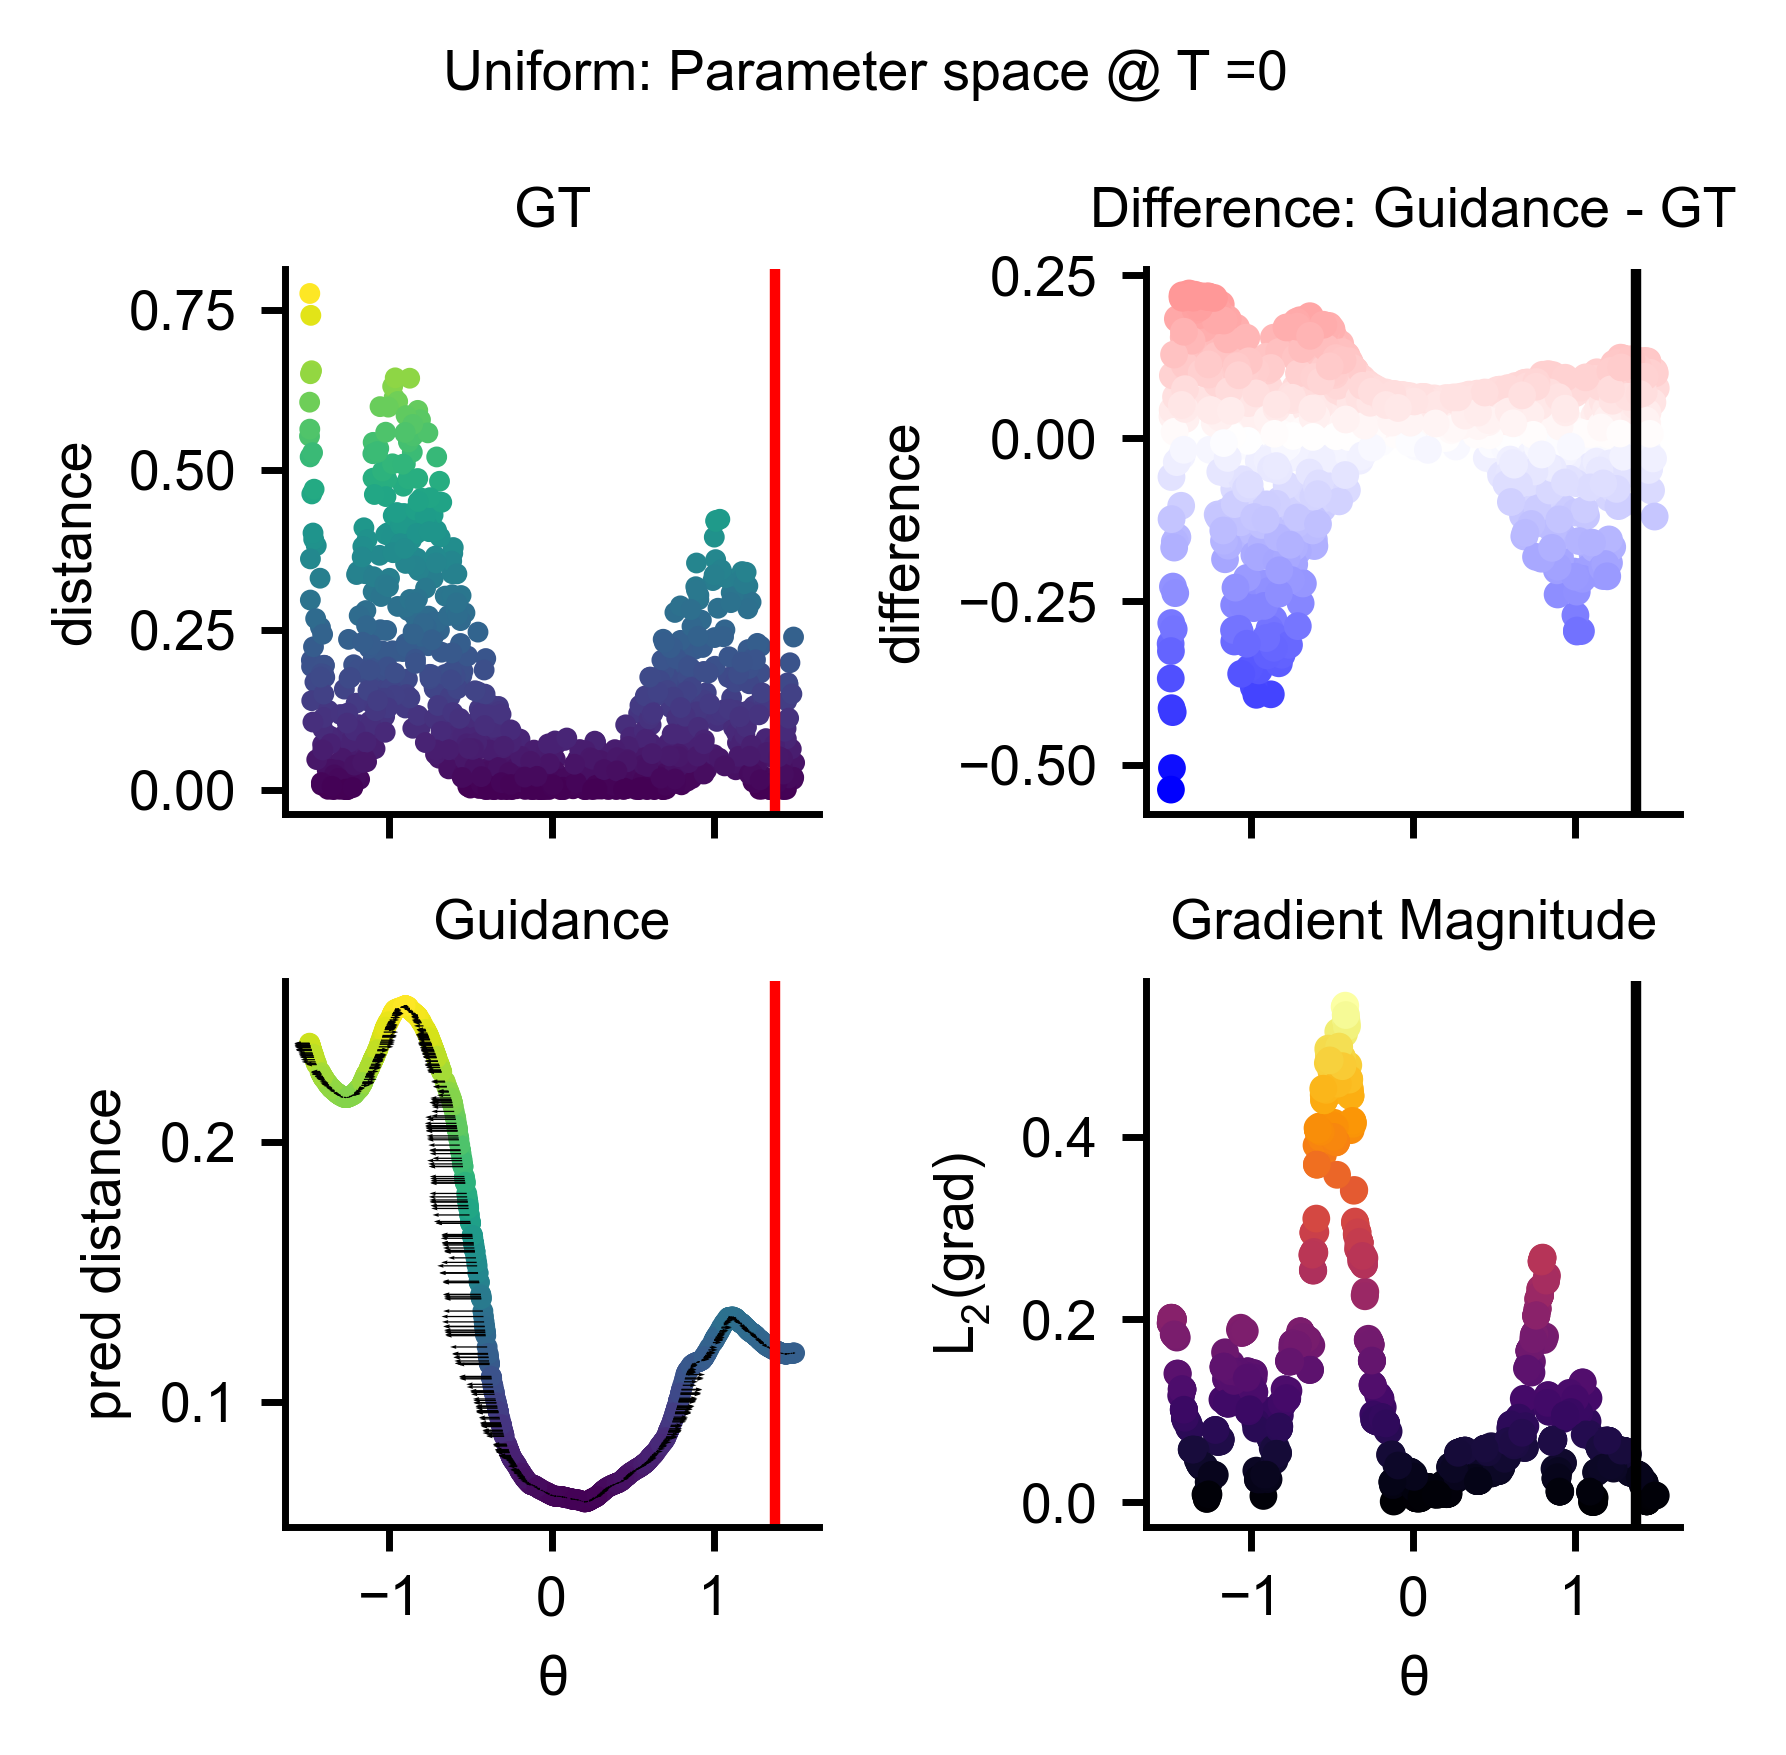

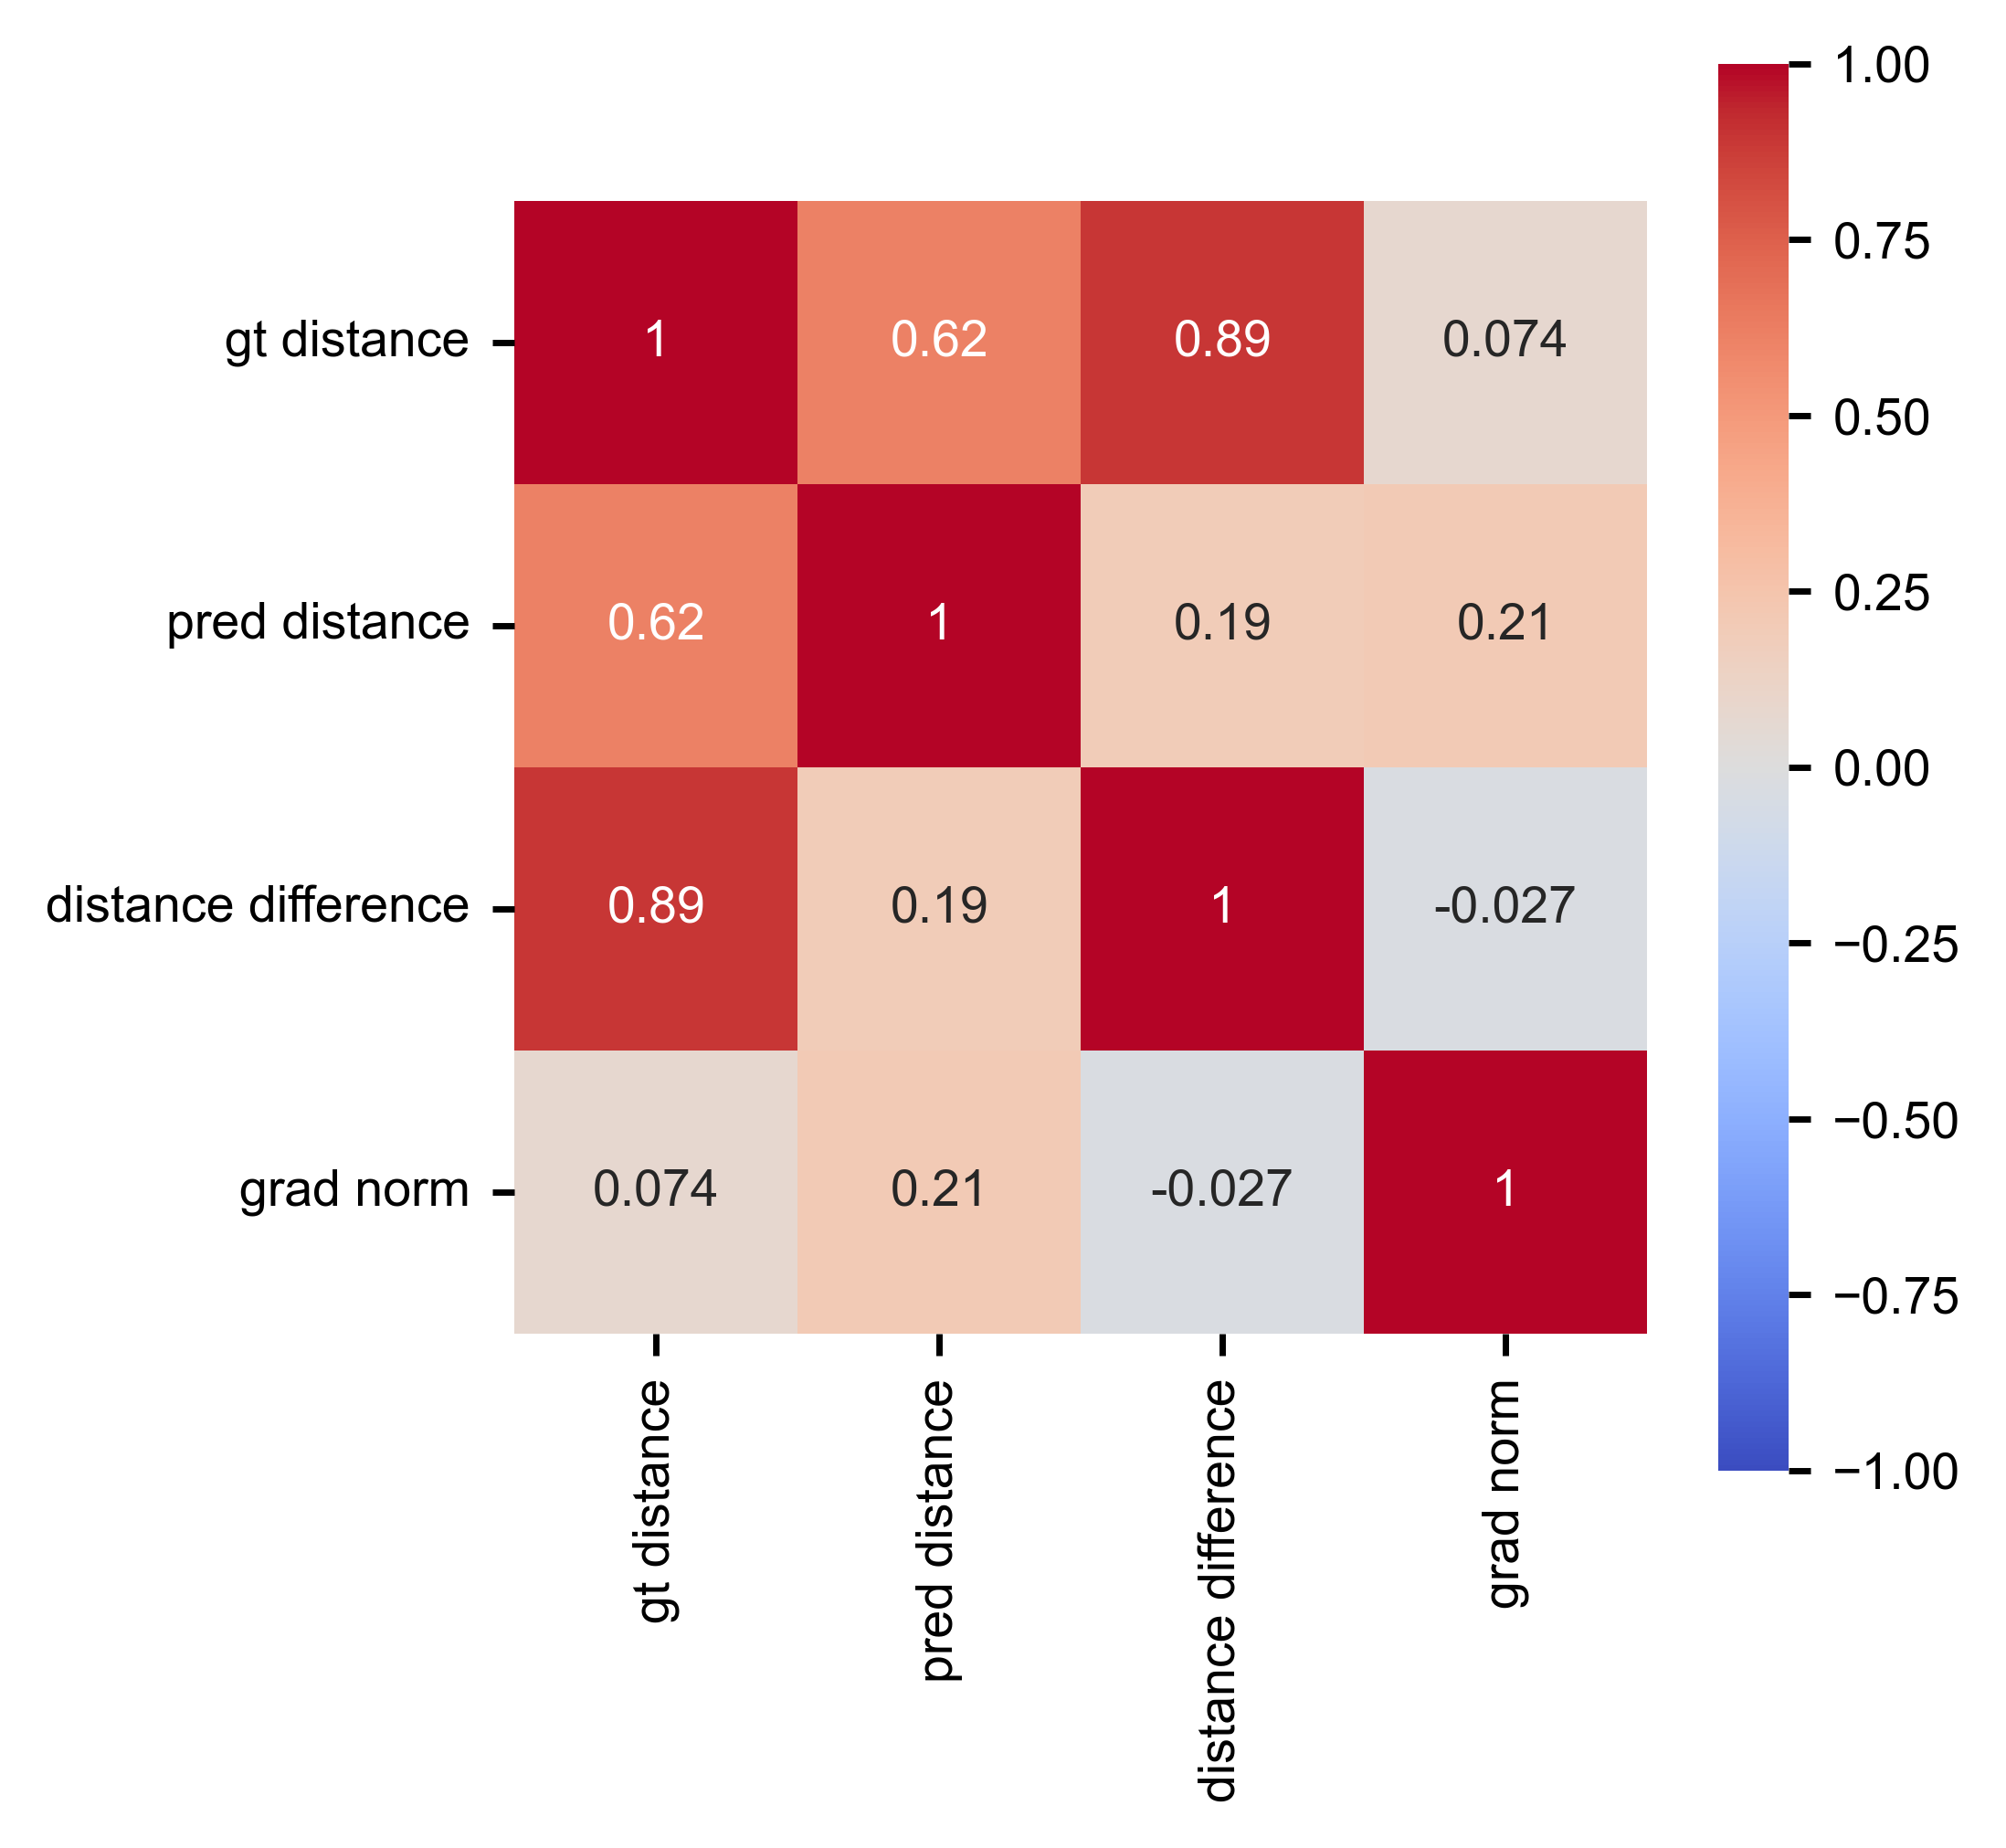

In [9]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.colors as mcolors


def plot_guidance_analytics_1D_minimal(
    samples: Tensor,
    gt_sample: Tensor,
    gt_distance: Tensor,
    pred_distance: Tensor,
    pred_grad: Tensor,
    gt_grad: Tensor = None,
    title: str = "",
):
    fig, axs = plt.subplots(ncols=2, nrows=2, sharex=True, figsize=(3.5, 3.5))
    ((ax1, ax2), (ax3, ax4)) = axs

    grad_norm = torch.linalg.norm(pred_grad, dim=-1)
    sort_idx = torch.argsort(samples.flatten())

    ax1.scatter(samples, gt_distance, c=gt_distance, s=4)
    if gt_grad is not None:
        ax1.quiver(samples, gt_distance, gt_grad, torch.zeros_like(pred_distance))
    ax1.axvline(gt_sample, c="r")
    ax1.set_title("GT")

    ax3.scatter(samples, pred_distance, c=pred_distance, s=4)
    ax3.quiver(samples, pred_distance, pred_grad, torch.zeros_like(pred_distance))
    ax3.axvline(gt_sample, c="r")
    ax3.set_title("Guidance")
        
    ax2.plot(samples.flatten()[sort_idx], gt_distance.flatten()[sort_idx], label="GT")
    ax2.plot(samples.flatten()[sort_idx], pred_distance.flatten()[sort_idx], label="Guidance")        
    ax2.axvline(gt_sample, c="k")
    ax2.set_title("Comparison: GT, Guidance")

    ax4.scatter(samples, grad_norm, c=grad_norm, cmap="inferno")
    ax4.axvline(gt_sample, c="k")
    ax4.plot(np.linspace(samples.min(), samples.max(), 100), 2 * (np.abs(np.linspace(samples.min() - gt_sample.numpy(), samples.max() - gt_sample.numpy(), 100))), "k--", label="GT gradient norm")
    ax4.set_title("Gradient Magnitude")
    
    fig.suptitle(title)
    fig.tight_layout()
    fig.legend(bbox_to_anchor=(1, 0.01), ncols=3)
    return fig, axs

x, theta = load_specified_data("../data/uniform_1000.pt")
dist_matrix = compute_distances(mse_dist, x, x)
gt_gradient = compute_distances(lambda x, y:  2 * (x - y), x, x)

idx = 3
T = 0

pred_dist, (theta_grad, x_grad) = get_guidance_analytics(theta[[idx]], x, guidance, T)
fig, axs = plot_guidance_analytics_1D_minimal(
    x,
    x[idx],
    dist_matrix[idx],
    pred_dist.squeeze(),
    x_grad,
    gt_gradient[idx],
    title=f"Uniform: Observation space @ {T =}",
)
axs[1, 0].set_xlabel(r"$x$")
axs[1, 1].set_xlabel(r"$x$")
axs[0, 0].set_ylabel("distance")
axs[1, 0].set_ylabel("pred distance")
axs[1, 1].set_ylabel(r"$L_2(grad)$")
fig.tight_layout()
fig.savefig("figures/guidance_eval_uniform_obs_space.pdf")

plot_corr(dist_matrix[idx], pred_dist, x_grad)

pred_dist, (theta_grad, x_grad) = get_guidance_analytics(theta, x[[idx]], guidance, T)
fig, axs = plot_guidance_analytics_1D(
    theta,
    theta[idx],
    dist_matrix[idx],
    pred_dist.squeeze(),
    theta_grad,
    title=f"Uniform: Parameter space @ {T =}",
)
axs[1, 0].set_xlabel(r"$\theta$")
axs[1, 1].set_xlabel(r"$\theta$")
axs[0, 0].set_ylabel("distance")
axs[0, 1].set_ylabel("difference")
axs[0, 1].set_xlabel(None)
axs[1, 0].set_ylabel("pred distance")
axs[1, 1].set_ylabel(r"$L_2(grad)$")
fig.tight_layout()
fig.savefig("figures/guidance_eval_uniform_param_space.pdf")
plot_corr(dist_matrix[idx], pred_dist, theta_grad)

Compute mse_dist distances: 100%|██████████| 1000/1000 [00:00<00:00, 36317.46sample/s]


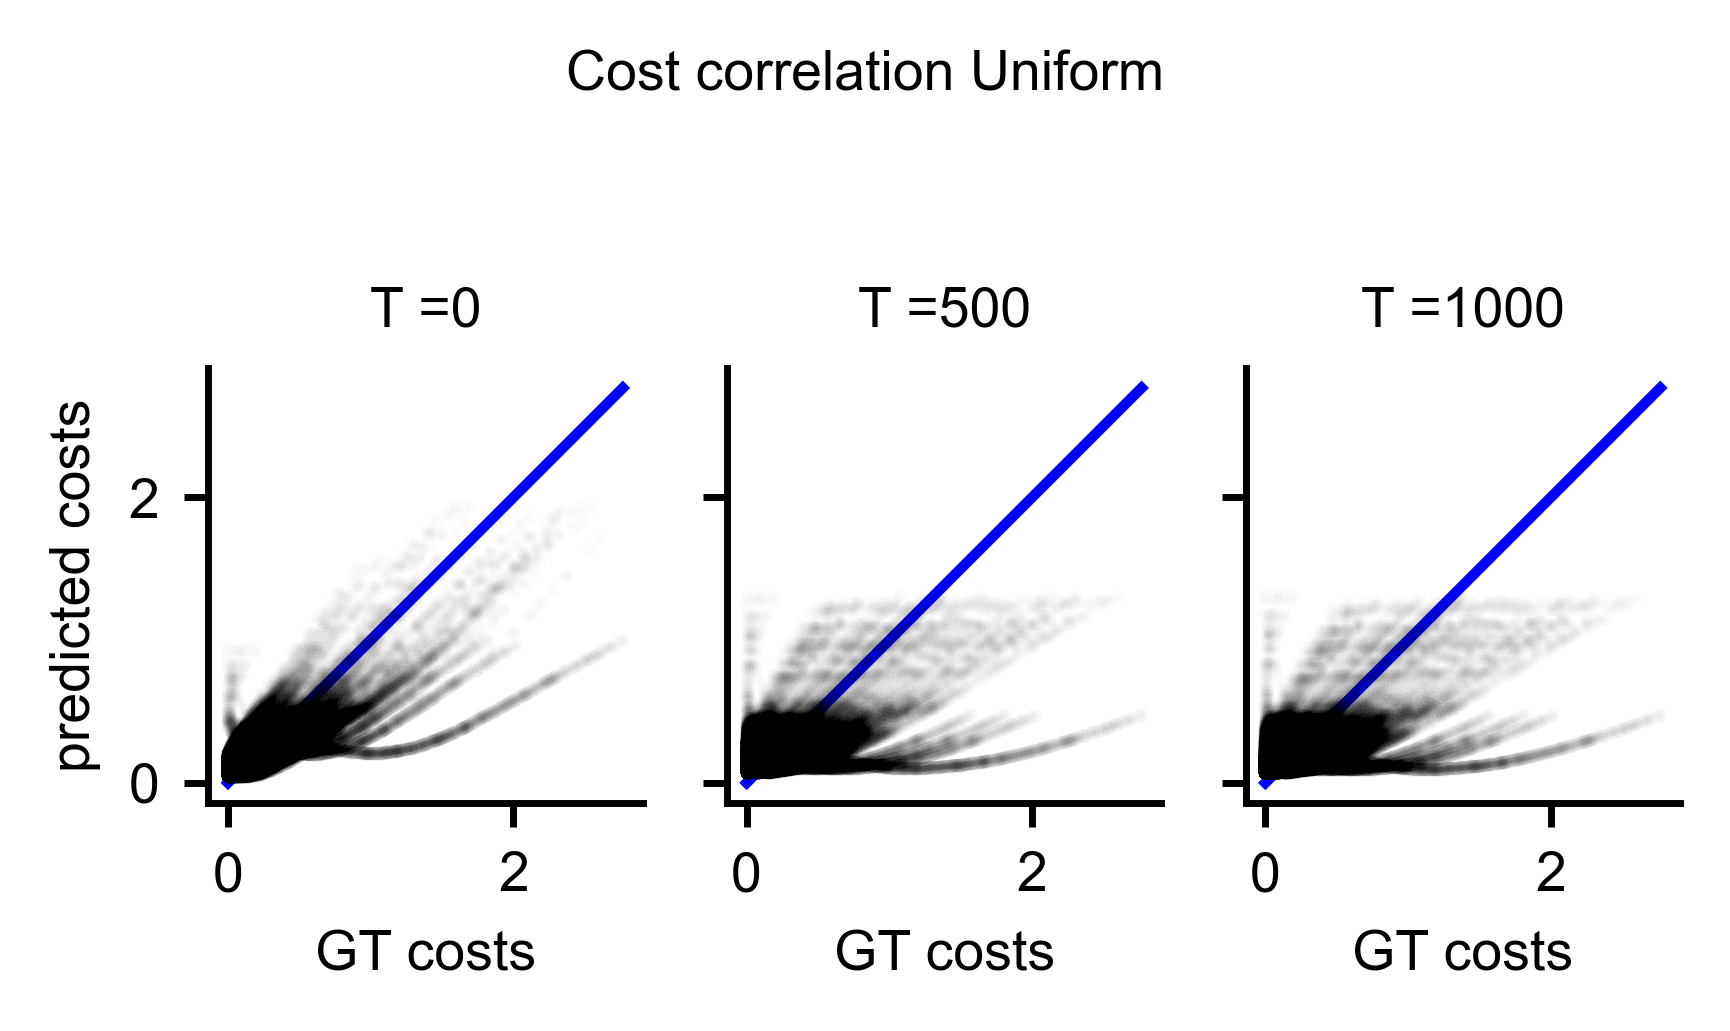

In [6]:
x, theta = load_specified_data("../data/uniform_1000.pt")
dist_matrix = compute_distances(mse_dist, x, x)

indices = np.arange(100)
fig, axs = plt.subplots(ncols=3, figsize=(3.5, 2), sharex=True, sharey=True)


for T, ax2 in zip([0, 500, 1000], (axs)):
    with torch.no_grad():
        time_repr = guidance.get_diff_time_repr(np.ones(len(indices)) * T)
        pred_dist = guidance.forward(theta[[indices]], x[None].repeat(len(indices), 1, 1), time_repr)

    outer = torch.maximum(dist_matrix[indices].max(), pred_dist.max())
    ax2.plot([0, outer], [0, outer], color="blue", zorder=-1)
    ax2.scatter(dist_matrix[indices].flatten(), pred_dist[:, :, 0].flatten(), s=1, alpha=0.01)
    ax2.set_title(f"{T =}")
    ax2.set_xlabel("GT costs")
    ax2.set_aspect("equal")

axs[0].set_ylabel("predicted costs")
fig.suptitle("Cost correlation Uniform")  
fig.tight_layout()
fig.savefig("figures/guidance_eval_cost_corr_uniform.pdf")



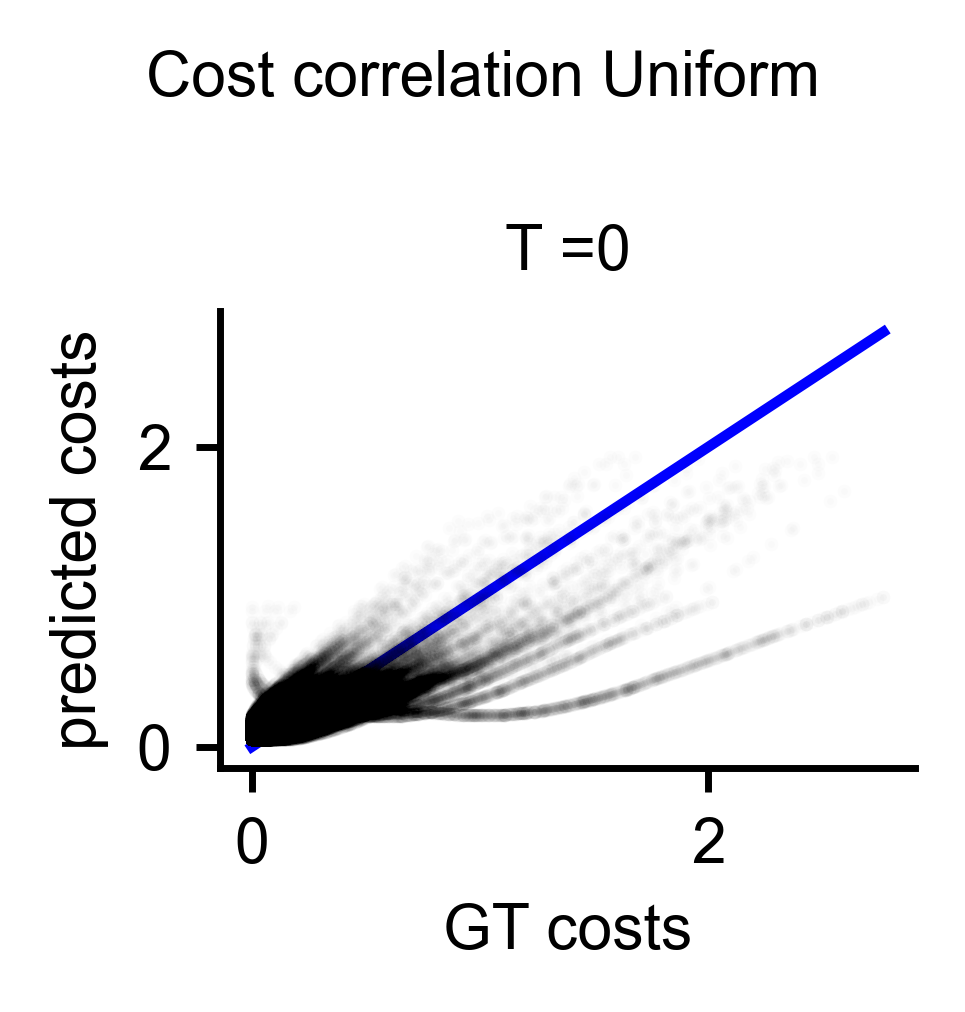

In [8]:
indices = np.arange(100)
fig, ax = plt.subplots(figsize=(2, 2), sharex=True, sharey=True)


with torch.no_grad():
    time_repr = guidance.get_diff_time_repr(np.ones(len(indices)) * 0)
    pred_dist = guidance.forward(theta[[indices]], x[None].repeat(len(indices), 1, 1), time_repr)

outer = torch.maximum(dist_matrix[indices].max(), pred_dist.max())
ax.plot([0, outer], [0, outer], color="blue", zorder=-1)
ax.scatter(dist_matrix[indices].flatten(), pred_dist[:, :, 0].flatten(), s=1, alpha=0.01)
ax.set_title(f"T =0")       
ax.set_xlabel("GT costs")

ax.set_ylabel("predicted costs")
fig.suptitle("Cost correlation Uniform")  
fig.tight_layout()
fig.savefig("figures/guidance_eval_cost_corr_uniform_T_0.png")


In [5]:
diffusion_ckpt = "/home/robin/projects/lab_project/neuralgbi_diffusion/results/train_denoiser/uniform/2025-04-03-09-18-13/lightning_logs/version_0/epoch=94-step=3800.ckpt"
config: Config = Config.from_file("../config/sampling_diffusion.yaml")
config.observed_data_file = "../data/gbi_data/misspecified_unknown/uniform_10.pt"
sampler = DiffusionSampler(
    diffusion_ckpt, res_net_guidance_ckpt, config.observed_data_file, config.beta, False, extended_information=True
)

In [6]:
sampler.update_gamma(100)
samples = sampler.forward(1000).detach()[..., 0]

Sample in observed data: 100%|██████████| 10/10 [00:54<00:00,  5.41s/it]


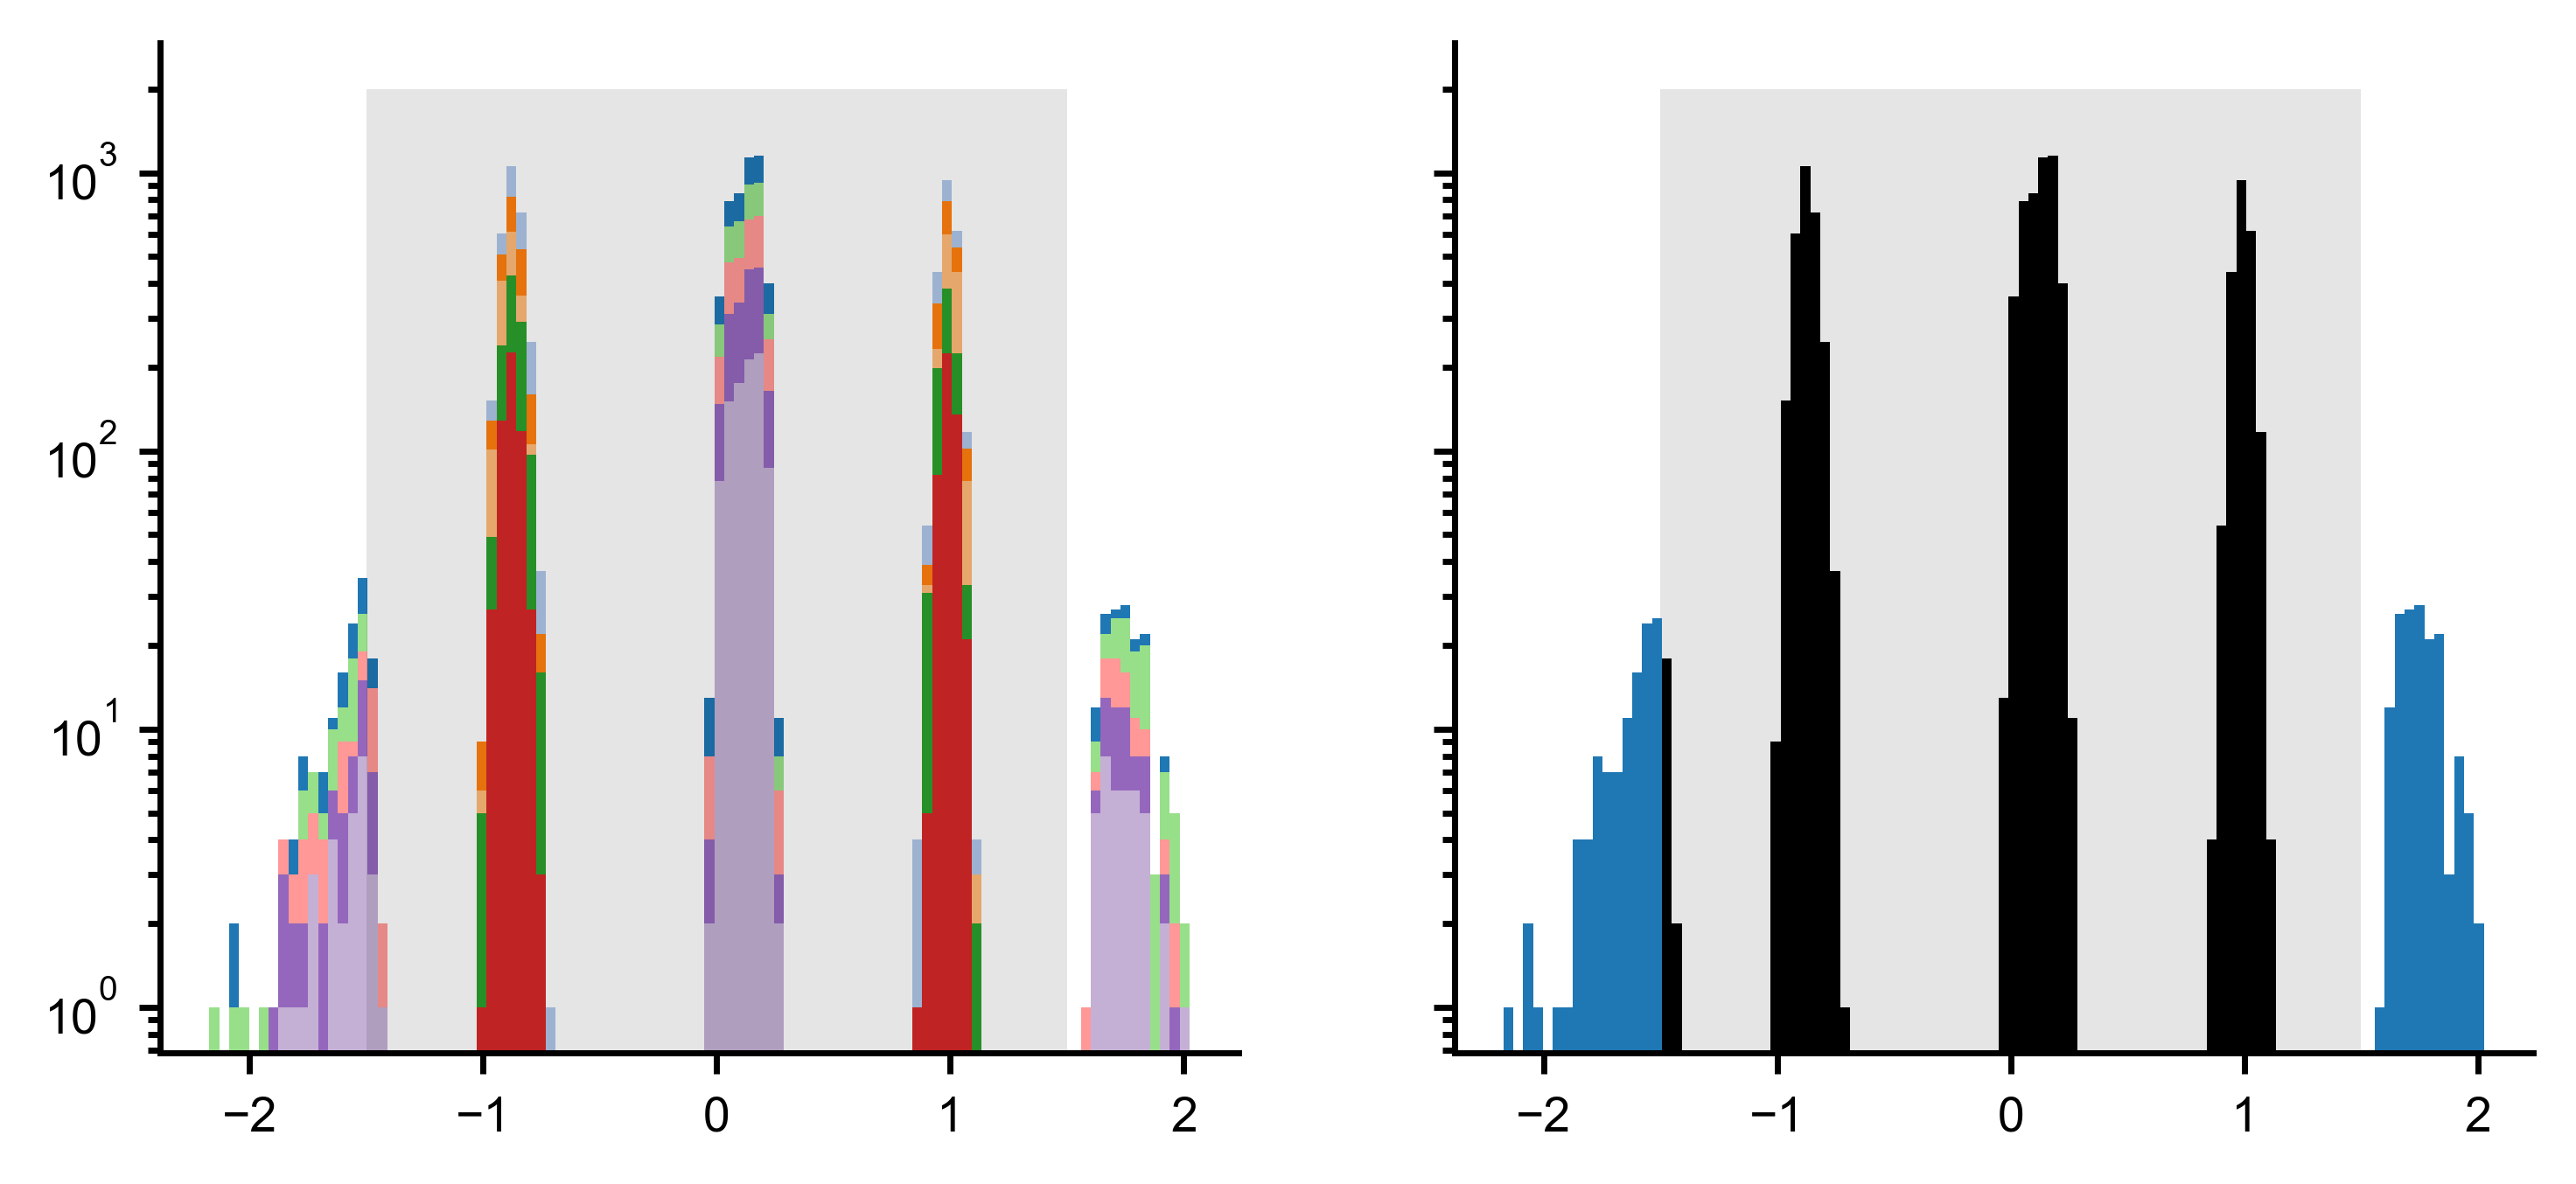

In [7]:
def in_rectangle(samples: Tensor, corrds: Tensor, stretch: Tensor) -> Tensor:
    """_summary_

    Args:
        samples (Tensor): (n_samples, feature_dim)
        corrds (Tensor): minimum corner (feature_dim, )
        stretch (Tensor): maximum corner (feature_dim, )

    Returns:
        Tensor: binary mask (n_samples, )
    """
    assert (stretch >= 0).prod(), "all elements of stretch have to be greater equal 0"
    mask = (samples >= corrds) * (samples <= (corrds + stretch))
    # mask = torch.prod(mask, dim=-1).bool()
    return mask


fig, (ax1, ax2) = plt.subplots(ncols=2, sharex=True, sharey=True, figsize=(7, 3))

bins = np.linspace(samples.min(), samples.max(), 100)
bin_width = bins[1] - bins[0]
hists = []
for sample_idx in range(samples.shape[0]):
    counts, _ = np.histogram(samples[sample_idx].flatten(), bins=bins)
    hists.append(counts)

hists = np.stack(hists)
for i, hist in enumerate(hists.cumsum(axis=0)[::-1]):
    ax1.bar(bins[:-1] + bin_width / 2, hist, bin_width, color=colors_tab20(i))
    
ax1.fill_betweenx((0, 2000), -1.5, 1.5, alpha=0.1)
ax2.fill_betweenx((0, 2000), -1.5, 1.5, alpha=0.1)
mask = in_rectangle(samples, torch.tensor((-1.5)), torch.tensor([3]))
ax2.hist(samples[mask].flatten(), bins=bins)
ax2.hist(samples[~mask].flatten(), bins=bins)
ax1.set_yscale("log")

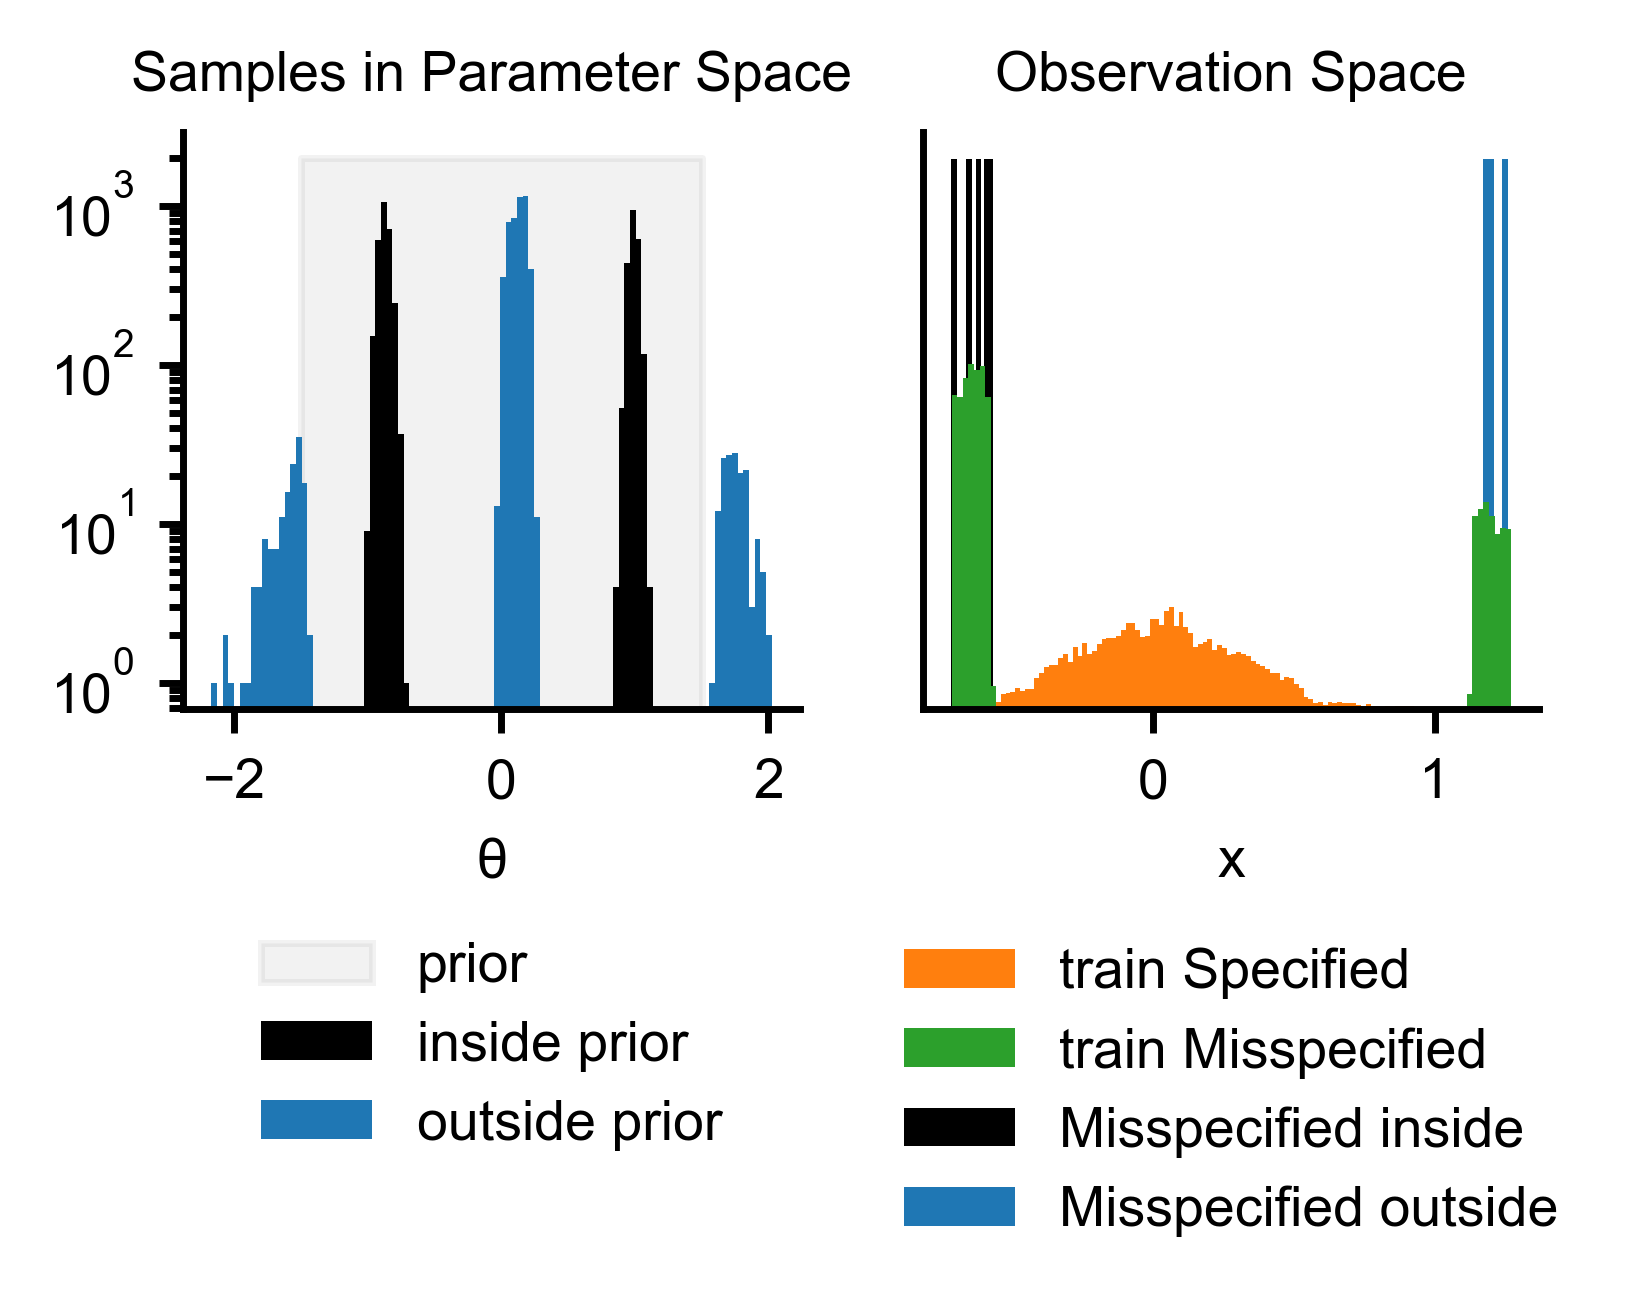

In [8]:
x_specified, _ = load_specified_data("../data/gbi_data/specified_unknown/uniform_10.pt")

fig, (ax1, ax3) = plt.subplots(ncols=2, sharex=False, sharey=False, figsize=(3.5, 1.5))
ax1.fill_betweenx((0, 2000), -1.5, 1.5, alpha=0.1, color="grey", label="prior")
# ax2.fill_betweenx((0, 2000), -1.5, 1.5, alpha=0.1, color="grey")

indices = [0, 1,2, 4, 9]
mask = np.ones(10)
mask[indices] = 0
mask = mask.astype(bool)
ax1.bar(bins[:-1] + bin_width / 2, hists[mask].sum(axis=0), bin_width, label="inside prior")
ax1.bar(bins[:-1] + bin_width / 2, hists[~mask].sum(axis=0), bin_width, label="outside prior")

# ax2.bar(sampler.theta_o[mask][:, 0], np.ones(mask.sum()) * 1000, 0.08, label="inside")
# ax2.bar(sampler.theta_o[~mask][:, 0], np.ones((~mask).sum())* 1000, 0.08, label="")

ax3.bar(sampler.x_o[mask][:, 0], np.ones(mask.sum()) * 1500, 0.02, label="Misspecified inside")
ax3.bar(sampler.x_o[~mask][:, 0], np.ones((~mask).sum())* 1500, 0.02, label="Misspecified outside")

# ax3.bar(x_specified.flatten(), np.ones(10) * 1500, 0.02, )

x_specified, _ = load_specified_data("../data/uniform_10000.pt")
ax3.hist(x_specified, bins=100, color=colors_tab10(1), label="train Specified")
x_misspecified, _ = load_misspecified_data("../data/uniform_10000.pt")
ax3.hist(x_misspecified, bins=100, color=colors_tab10(2), label="train Misspecified")



ax1.set_xlabel(r"$\theta$")
ax3.set_xlabel(r"$x$")
ax1.set_yscale("log")
ax1.set_title("Samples in Parameter Space")
# ax2.set_title("GT in Parameter Space")
ax3.set_title("Observation Space")

ax1.legend(loc="lower center", ncols=1, bbox_to_anchor=(0.5, -0.85))
#ax2.legend()
ax3.legend(loc="lower center", ncols=1, bbox_to_anchor=(0.5, -1))
ax3.set_yticks([], [])

fig.savefig("figures/Insights_misspecified_uniform-sampling.pdf")   

/tmp/ipykernel_60079/585684627.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels([None, *(np.linspace(0, 1, 5)[::-1] * 1000).astype(int)])


torch.Size([10, 1001, 1000, 1])
torch.Size([10, 1000, 1000])
torch.Size([9707, 1000])


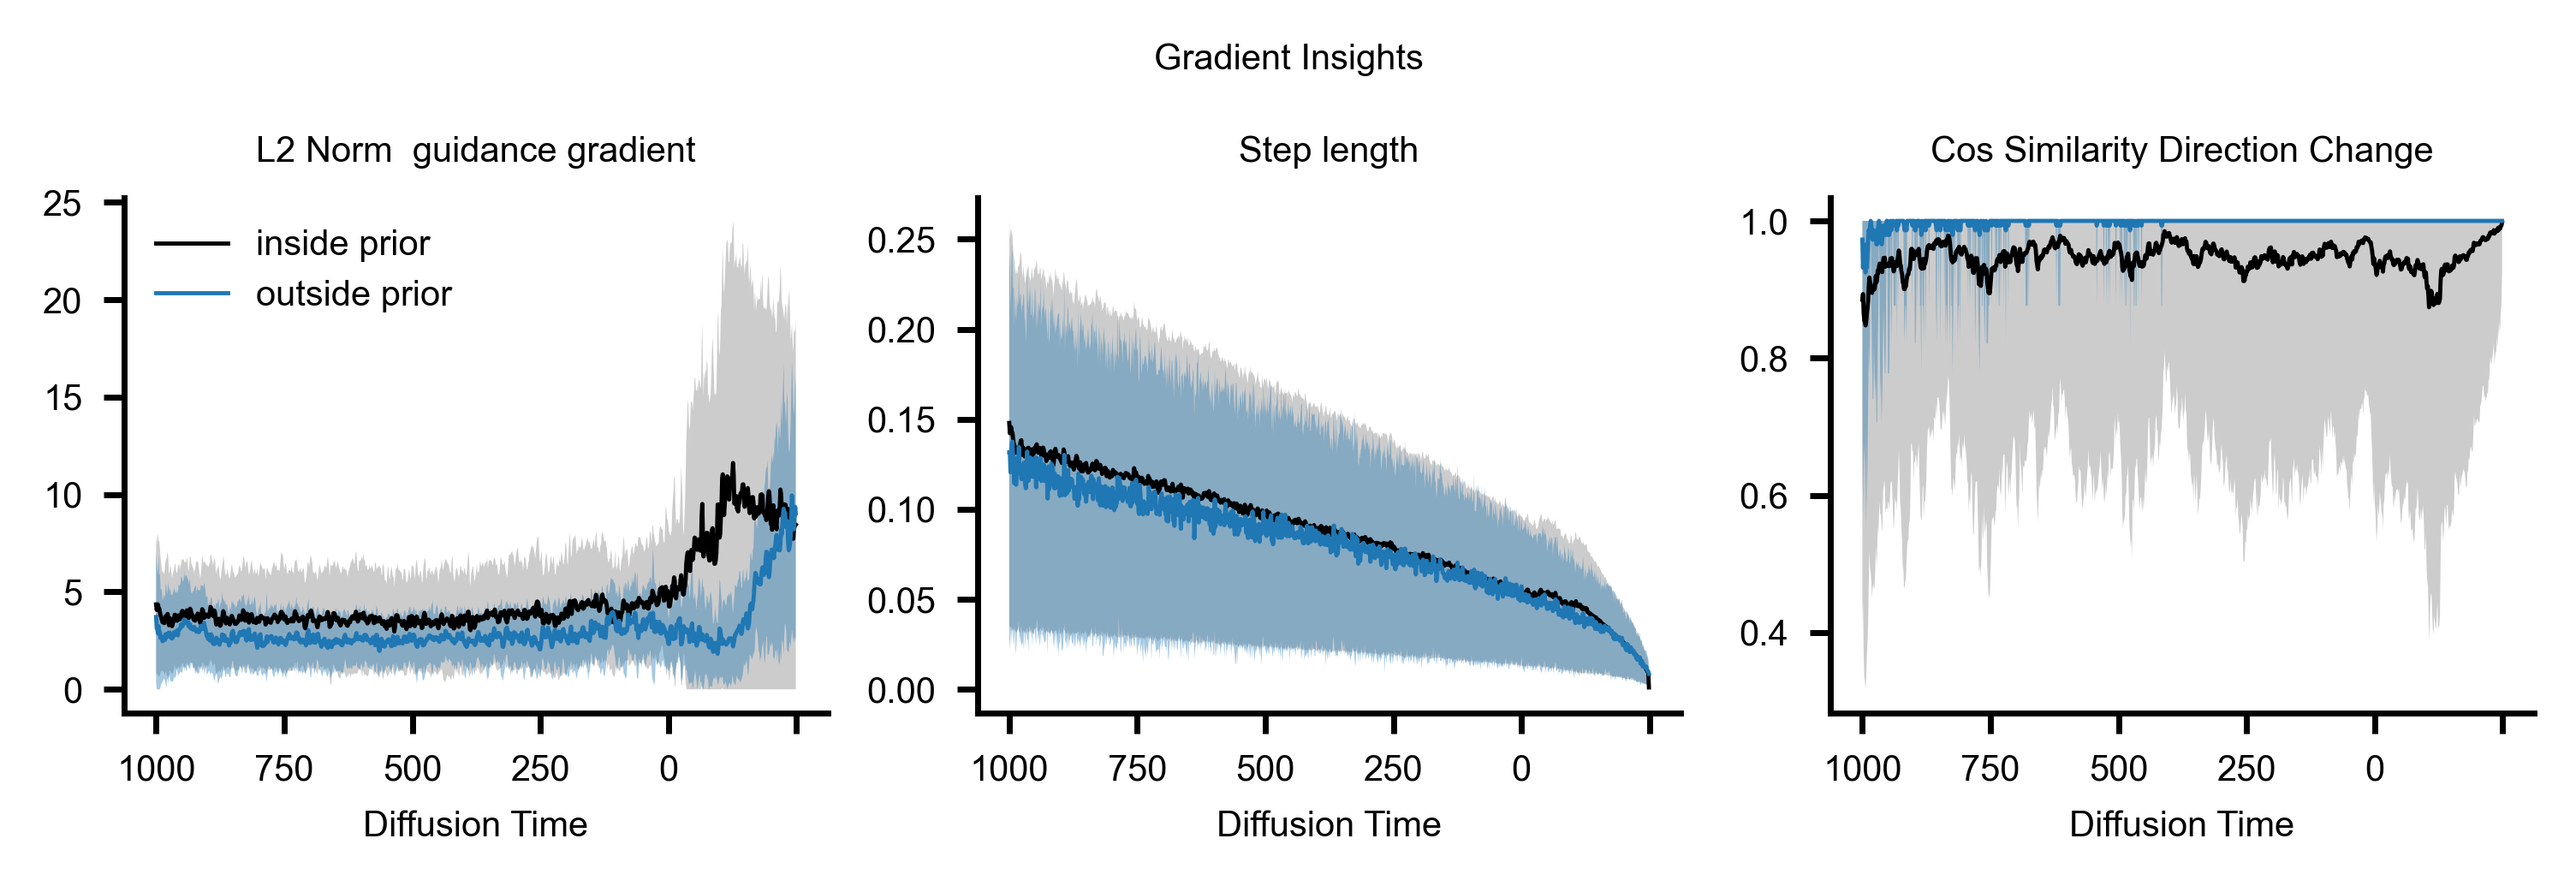

In [120]:
fig, (ax1, ax3, ax2) = plt.subplots(ncols=3, sharex=True, figsize=(6, 2))
mask = in_rectangle(samples, torch.tensor((-1.5)), torch.tensor([3]))

ax1.set_xticklabels([None, *(np.linspace(0, 1, 5)[::-1] * 1000).astype(int)])
ax1.set_title("L2 Norm  guidance gradient")

guidance_grads = sampler._info["guidance_grad"]
guidance_stats = torch.linalg.norm(guidance_grads, dim=-1)
guidance_stats = guidance_stats.swapdims(1, 2)

ax1.fill_between(
    range(1000),
    torch.clip(guidance_stats[mask].mean(dim=0) - guidance_stats[mask].std(dim=0), 0),
    guidance_stats[mask].mean(dim=0) + guidance_stats[mask].std(dim=0),
    alpha=0.2,
)
ax1.plot(guidance_stats[mask].mean(dim=0), label="inside prior", linewidth=0.7)
ax1.fill_between(
    range(1000),
    torch.clip(guidance_stats[~mask].mean(dim=0) - guidance_stats[~mask].std(dim=0), 0),
    guidance_stats[~mask].mean(dim=0) + guidance_stats[~mask].std(dim=0),
    alpha=0.4,
)
ax1.plot(guidance_stats[~mask].mean(dim=0), label="outside prior", linewidth=0.7)
ax1.set_xlabel("Diffusion Time")
ax1.legend()

trajectory = sampler._info["trajectory"]
step_length = torch.linalg.norm(torch.diff(trajectory, dim=1), dim=-1)
step_length = step_length.swapdims(1, 2)

ax3.fill_between(
    range(1000),
    step_length[mask].mean(dim=0) - step_length[mask].std(dim=0),
    step_length[mask].mean(dim=0) + step_length[mask].std(dim=0),
    alpha=0.2,
)
ax3.plot(step_length[mask].mean(dim=0), label="inside prior", linewidth=0.7)
ax3.fill_between(
    range(1000),
    step_length[~mask].mean(dim=0) - step_length[~mask].std(dim=0),
    step_length[~mask].mean(dim=0) + step_length[~mask].std(dim=0),
    alpha=0.4,
)
ax3.plot(step_length[~mask].mean(dim=0), label="outside prior", linewidth=0.7)
ax3.set_xlabel("Diffusion Time")
ax3.set_title("Step length")

print(trajectory.shape)
traj_dir_change = (
    torch.sum(trajectory[:, :-1] * trajectory[:, 1:], dim=-1)
    / torch.linalg.norm(trajectory[:, :-1], dim=-1)
    / torch.linalg.norm(trajectory[:, 1:], dim=-1)
)
# traj_dir_change = torch.arccos(traj_dir_change)
print(traj_dir_change.shape)
traj_dir_change = traj_dir_change.swapdims(1, 2)
print(traj_dir_change[mask].shape)
ax2.fill_between(
    range(1000),
    traj_dir_change[mask].mean(dim=0) - traj_dir_change[mask].std(dim=0),
    torch.clip(traj_dir_change[mask].mean(dim=0) + traj_dir_change[mask].std(dim=0), max=1),
    alpha=0.2,
)
# ax3.plot(traj_dir_change[mask].T, linewidth=0.1, color="k")
# ax3.plot(traj_dir_change[~mask].T, linewidth=0.5, color=colors_tab10(0))
ax2.plot(traj_dir_change[mask].mean(dim=0), label="inside prior", linewidth=0.7)
ax2.fill_between(
    range(1000),
    traj_dir_change[~mask].mean(dim=0) - traj_dir_change[~mask].std(dim=0),
    torch.clip(traj_dir_change[~mask].mean(dim=0) + traj_dir_change[~mask].std(dim=0), max=1),
alpha=0.4,      
)
ax2.plot(traj_dir_change[~mask].mean(dim=0), label="outside prior", linewidth=0.7)
ax2.set_title("Cos Similarity Direction Change")
ax2.set_xlabel("Diffusion Time")
fig.suptitle("Gradient Insights")
fig.tight_layout()
fig.savefig("figures/Insights_misspecified_uniform-sampling_gradient.png")

TypeError: Axes.scatter() missing 1 required positional argument: 'y'

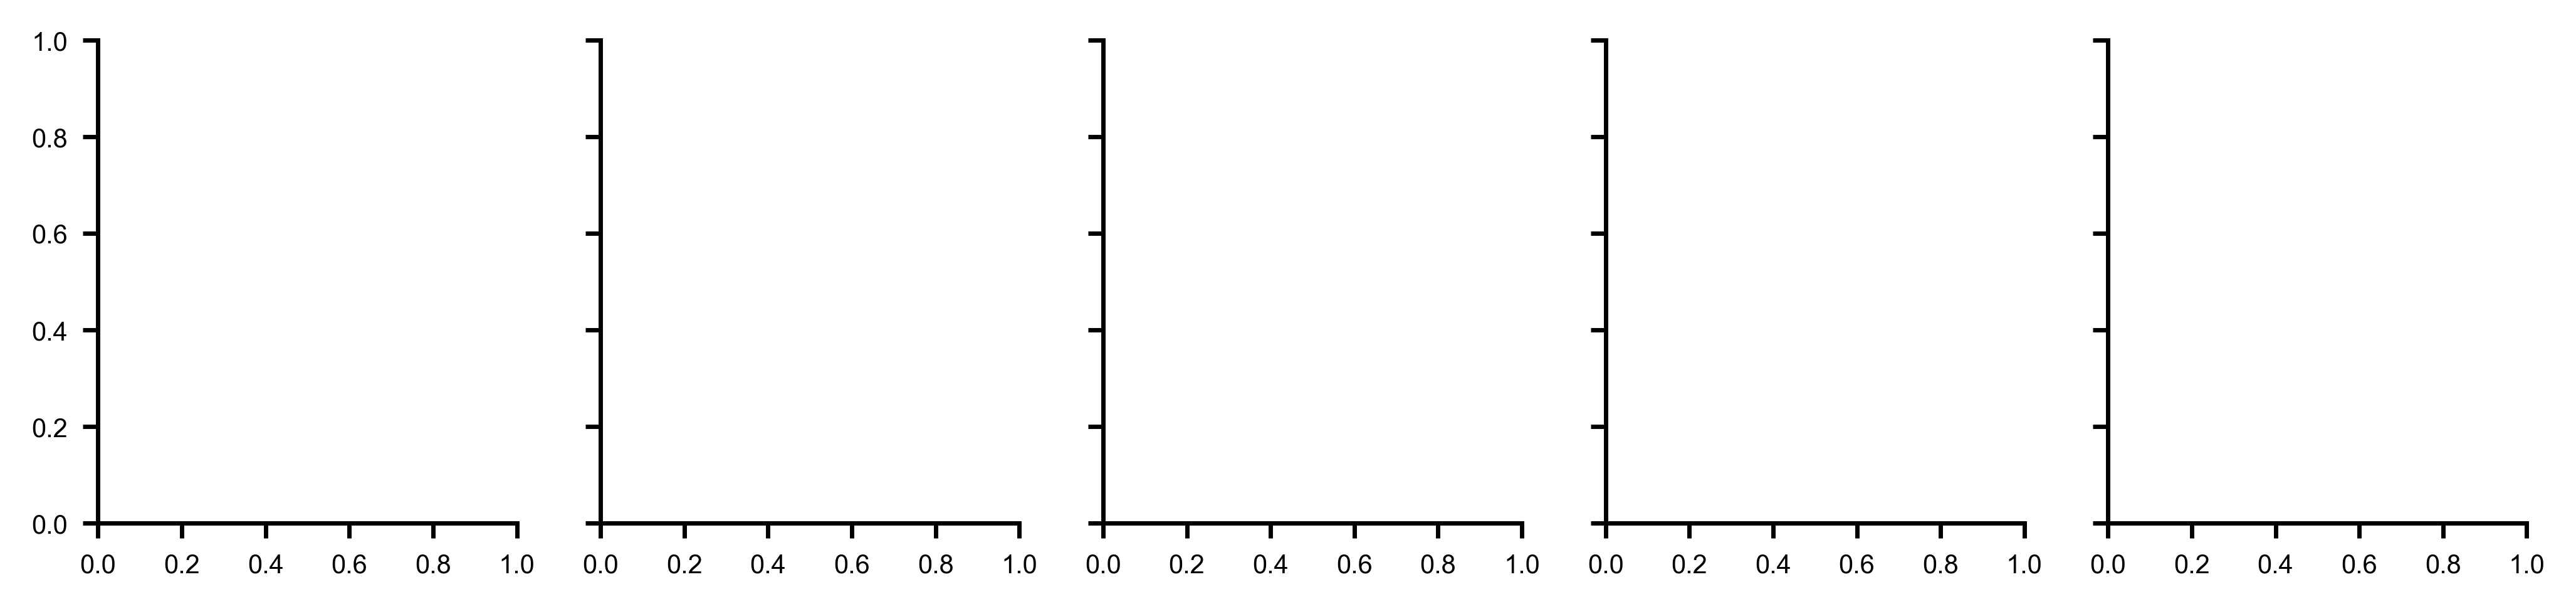

: 

In [ ]:
sample_idx = 8
times = [0, 20, 40, 60, 80]
fig, axs = plt.subplots(ncols=len(times), sharex=True, sharey=True, figsize=(10, 2))
for idx, t in enumerate(times):
    axs[idx].scatter(*trajectory[sample_idx,t, mask[sample_idx]].T, s=1, label="inside prior")
    axs[idx].scatter(*trajectory[sample_idx,t, ~mask[sample_idx]].T, s=1, label="outside prior")
    axs[idx].set_title(f"t={1000 - t}")
axs[0].legend()
fig.suptitle("Two Moons, Observation Space across Diffusion Time, beta=400")
fig.tight_layout()


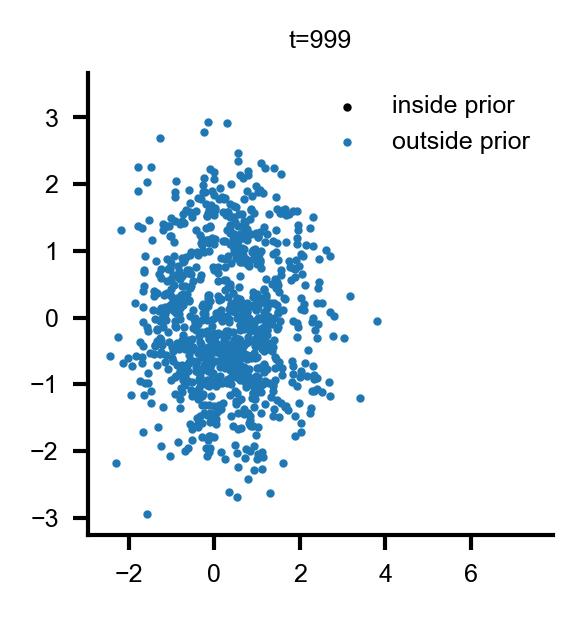

: 

In [ ]:
from matplotlib.animation import FuncAnimation, PillowWriter

fig, ax2 = plt.subplots(figsize=(2, 2))
title = ax2.set_title(f"t={1000}")
inside_scat = ax2.scatter(
    *trajectory[sample_idx, 0, mask[sample_idx]].T, s=1, label="inside prior"
)
outside_scat = ax2.scatter(
    *trajectory[sample_idx, 0, ~mask[sample_idx]].T, s=1, label="outside prior"
)

x_lim = (trajectory[sample_idx, ..., 0].min(), trajectory[sample_idx, ..., 0].max())
y_lim = (trajectory[sample_idx, ..., 1].min(), trajectory[sample_idx, ..., 1].max())
ax_x_lim = ax2.set_xlim(x_lim)
ax_y_lim = ax2.set_ylim(y_lim)
ax2.legend()

def animate(t,):
    title.set_text(f"t={1000 - t}")
    inside_scat.set_offsets(trajectory[sample_idx, t, mask[sample_idx]])
    outside_scat.set_offsets(trajectory[sample_idx, t, ~mask[sample_idx]])
    return inside_scat, outside_scat


ani = FuncAnimation(fig, animate, repeat=True, frames=range(1, 1001) , interval=50)
writer = PillowWriter(fps=15, metadata=dict(artist="Me"), bitrate=1800)
ani.save("gaussian_mixture_scatter.gif", writer=writer)